# Titanic Survival Analysis

In this notebook I am performing exploratory data analysis (EDA) on the Titanic dataset to understand what factors influenced whether a passenger survived. I will clean the data, handle missing values, and then create visualizations to look at survival rates by class, gender, age, and a few other features.

## 1. Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

## 2. Loading the Dataset

In [2]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Basic Exploration

In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Age, Cabin, and Embarked all have missing values. Cabin is missing for most rows, so I will drop that column. For Age I will fill in the missing values with the median, and for Embarked I will fill the missing values with the most common port.

## 4. Data Cleaning

In [7]:
df.drop(columns=['Cabin'], inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## 5. Labeling Survival and Age Groups

The 'Survived' column only has 0s and 1s, so I used a `match` statement to turn it into a readable label. I also used a `match` statement to group passengers into age categories.

In [9]:
def survival_label(value):
    match value:
        case 1:
            return 'Survived'
        case 0:
            return 'Did Not Survive'
        case _:
            return 'Unknown'

df['Survival_Status'] = df['Survived'].apply(survival_label)
df[['Name', 'Survived', 'Survival_Status']].head(10)

,Name,Survived,Survival_Status
0,"Braund, Mr. Owen Harris",0,Did Not Survive
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,Survived
2,"Heikkinen, Miss. Laina",1,Survived
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,Survived
4,"Allen, Mr. William Henry",0,Did Not Survive
5,"Moran, Mr. James",0,Did Not Survive
6,"McCarthy, Mr. Timothy J",0,Did Not Survive
7,"Palsson, Master. Gosta Leonard",0,Did Not Survive
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,Survived
9,"Nasser, Mrs. Nicholas (Adele Achem)",1,Survived


In [10]:
def age_group(age):
    match age:
        case a if a < 13:
            return 'Child'
        case a if a < 20:
            return 'Teenager'
        case a if a < 60:
            return 'Adult'
        case _:
            return 'Senior'

df['Age_Group'] = df['Age'].apply(age_group)
df[['Name', 'Age', 'Age_Group']].head(10)

,Name,Age,Age_Group
0,"Braund, Mr. Owen Harris",22.0,Adult
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,Adult
2,"Heikkinen, Miss. Laina",26.0,Adult
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,Adult
4,"Allen, Mr. William Henry",35.0,Adult
5,"Moran, Mr. James",28.0,Adult
6,"McCarthy, Mr. Timothy J",54.0,Adult
7,"Palsson, Master. Gosta Leonard",2.0,Child
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.0,Adult
9,"Nasser, Mrs. Nicholas (Adele Achem)",14.0,Teenager


## 6. Overall Survival Rate

In [11]:
df['Survival_Status'].value_counts()

Survival_Status
Did Not Survive    549
Survived           342
Name: count, dtype: int64

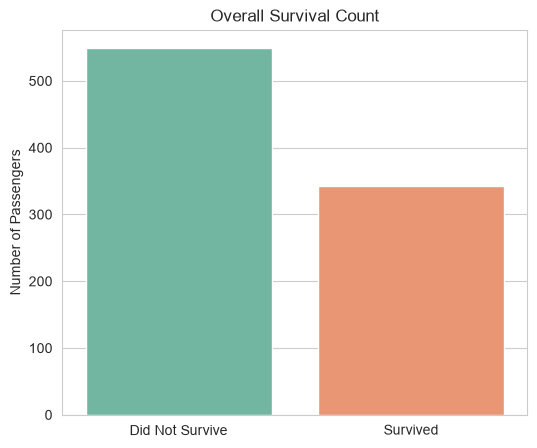

In [12]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Survival_Status', hue='Survival_Status', palette='Set2', legend=False)
plt.title('Overall Survival Count')
plt.xlabel('')
plt.ylabel('Number of Passengers')
plt.show()

## 7. Survival Rate by Passenger Class

In [13]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

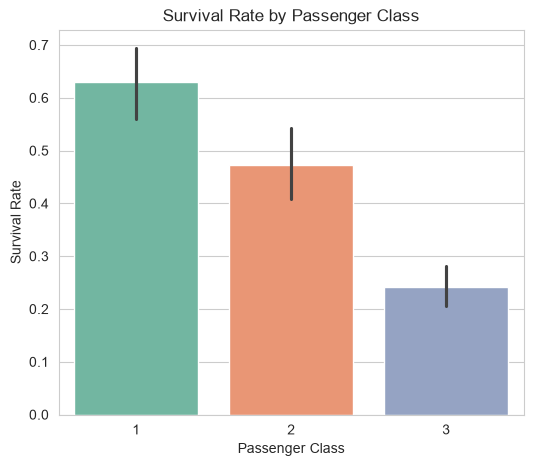

In [14]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='Pclass', y='Survived', hue='Pclass', palette='Set2', legend=False)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

## 8. Survival Rate by Gender

In [15]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

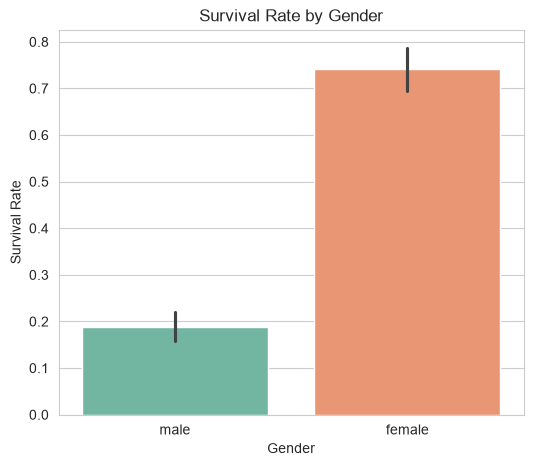

In [16]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='Sex', y='Survived', hue='Sex', palette='Set2', legend=False)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()

## 9. Survival Rate by Age Group

In [17]:
df.groupby('Age_Group')['Survived'].mean()

Age_Group
Adult       0.365193
Child       0.579710
Senior      0.269231
Teenager    0.410526
Name: Survived, dtype: float64

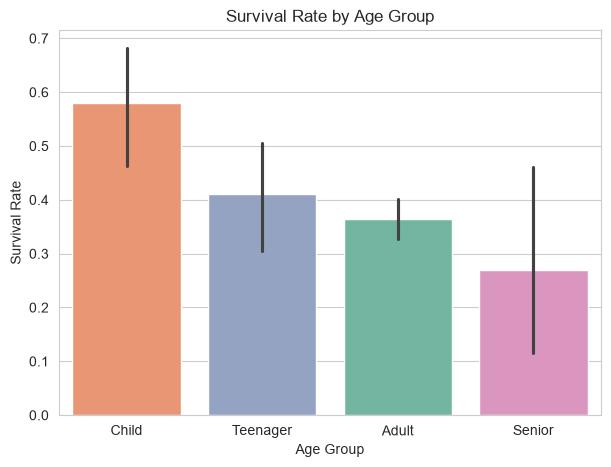

In [18]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='Age_Group', y='Survived', hue='Age_Group', order=['Child','Teenager','Adult','Senior'], palette='Set2', legend=False)
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.show()

## 10. Age Distribution by Survival

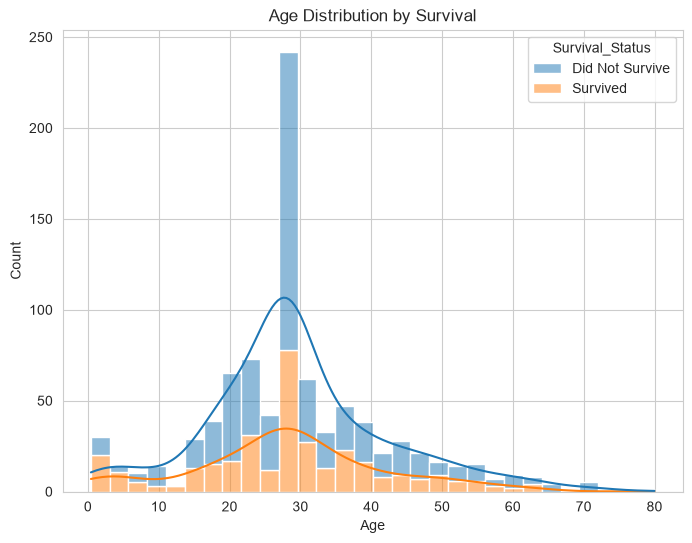

In [19]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='Age', hue='Survival_Status', bins=30, kde=True, multiple='stack')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.show()

## 11. Survival by Class and Gender Combined

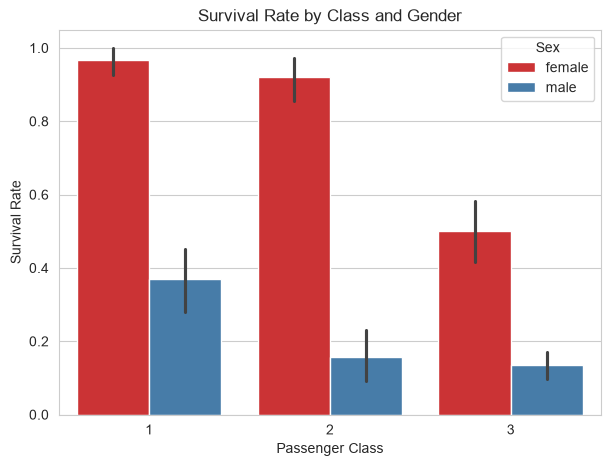

In [20]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', palette='Set1')
plt.title('Survival Rate by Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

## 12. Survival Rate by Embarkation Port

In [21]:
df.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64

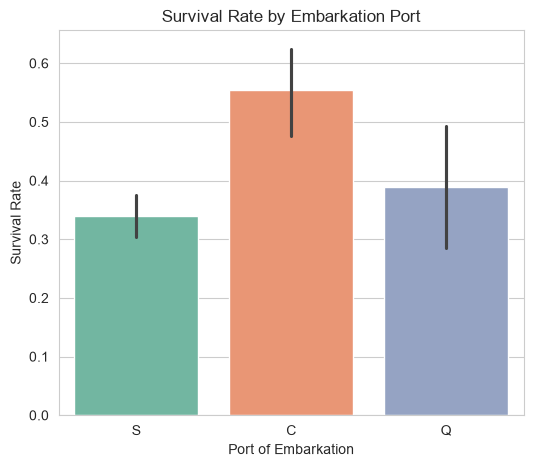

In [22]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='Embarked', y='Survived', hue='Embarked', palette='Set2', legend=False)
plt.title('Survival Rate by Embarkation Port')
plt.xlabel('Port of Embarkation')
plt.ylabel('Survival Rate')
plt.show()

## 13. Correlation Between Numerical Features

In [23]:
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df[num_cols].corr()
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


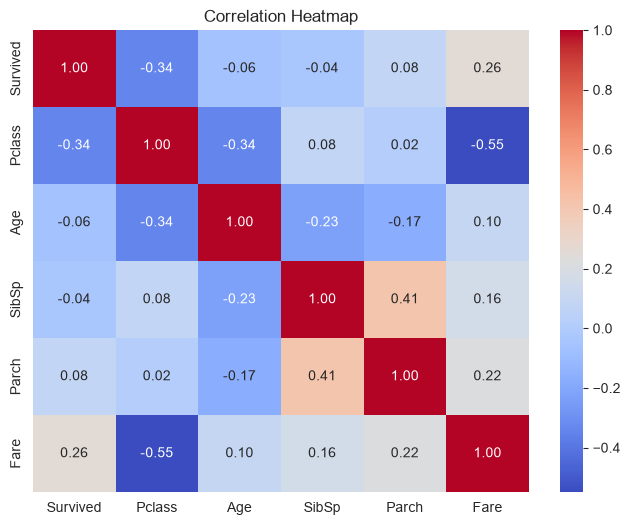

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 14. Conclusion

From this analysis, gender was one of the strongest factors in survival, with women surviving at a much higher rate than men. Passenger class also mattered a lot, since first class passengers survived more often than second or third class passengers. Younger passengers, especially children, had a better chance of survival compared to adults. Fare and class are related, which makes sense since higher fares usually meant a higher class cabin and easier access to lifeboats.